# Notebook 3 — Modélisation ML
## ImmoPredict SN — Prédiction des Prix
**Modèles :** XGBoost, LightGBM, Random Forest, Ridge + Stacking
---

In [18]:
import pandas as pd
import numpy as np
import json, joblib, os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

import xgboost as xgb
import lightgbm as lgb

try:
    import shap
    HAS_SHAP = True
except: HAS_SHAP = False

GOLD='#C9A84C'; NAVY='#0F2444'; GREEN='#0E6B4A'
np.random.seed(42)

# ── Charger la config produite par NB2 ──────────────────────────
with open('../properties/ml/features_config.json') as f:
    cfg = json.load(f)

# NB2 écrit les clés NUM_FEATURES et CAT_FEATURES
df = pd.read_csv('../data/dataset_features.csv')
df = df.dropna(subset=['log_price'])   # log_price créé dans NB2

avail_num = [f for f in cfg['NUM_FEATURES'] if f in df.columns]
avail_cat = [f for f in cfg['CAT_FEATURES'] if f in df.columns]
ALL_FEATS = avail_num + avail_cat

X = df[ALL_FEATS]
y = df['log_price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'✅ {len(df):,} annonces chargées depuis NB2')
print(f'   Features numériques : {len(avail_num)}')
print(f'   Features catégorielles : {len(avail_cat)}')
print(f'   Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'   Transactions: {df["transaction"].value_counts().to_dict() if "transaction" in df.columns else "N/A"}')

✅ 9,376 annonces chargées depuis NB2
   Features numériques : 46
   Features catégorielles : 2
   Train: 7,500 | Test: 1,876
   Transactions: {'Location': 6232, 'Vente': 3144}


In [19]:
# ── Préparation des données ───────────────────────────────────
# Utiliser log(price) comme cible (normalise la distribution skewed)
df['log_price'] = np.log1p(df['price'])

# Vérifier features disponibles
avail_num = [f for f in avail_num if f in df.columns]
avail_cat = [f for f in avail_cat if f in df.columns]
X = df[avail_num + avail_cat].copy()
y = df['log_price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# ── Préprocesseur ────────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Autre')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, avail_num),
    ('cat', cat_pipe, avail_cat),
])

print('✅ Préprocesseur créé')

Train: 7,500 | Test: 1,876
✅ Préprocesseur créé


In [20]:
# ── Fonction d'évaluation ─────────────────────────────────────
def evaluate(name, y_true, y_pred_log):
    """Évalue un modèle — reconvertit depuis log scale."""
    y_true_real = np.expm1(y_true)
    y_pred_real = np.expm1(y_pred_log)
    
    r2   = r2_score(y_true, y_pred_log)  # R² en log scale
    mae  = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    mape = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real.clip(1))) * 100
    pct20 = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real.clip(1)) <= 0.20) * 100
    pct30 = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real.clip(1)) <= 0.30) * 100
    
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  R²     : {r2:.4f}  ({"✅" if r2 > 0.85 else "⚠️"})')
    print(f'  MAE    : {mae/1e6:.2f}M FCFA')
    print(f'  RMSE   : {rmse/1e6:.2f}M FCFA')
    print(f'  MAPE   : {mape:.1f}%  ({"✅" if mape < 20 else "⚠️"})')
    print(f'  ±20%   : {pct20:.1f}%  ({"✅" if pct20 > 70 else "⚠️"})')
    print(f'  ±30%   : {pct30:.1f}%')
    return {'name':name,'r2':r2,'mae':mae,'rmse':rmse,'mape':mape,'pct20':pct20,'pct30':pct30}

results = {}

In [21]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 1 : XGBoost
# ══════════════════════════════════════════════════════════════
xgb_model = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ))
])

xgb_model.fit(X_train, y_train)
results['xgboost'] = evaluate('XGBoost', y_test, xgb_model.predict(X_test))


  XGBoost
  R²     : 0.6865  (⚠️)
  MAE    : 22.99M FCFA
  RMSE   : 90.20M FCFA
  MAPE   : 652846.3%  (⚠️)
  ±20%   : 28.0%  (⚠️)
  ±30%   : 38.8%


In [22]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 2 : LightGBM
# ══════════════════════════════════════════════════════════════
lgb_model = Pipeline([
    ('prep', preprocessor),
    ('model', lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ))
])

lgb_model.fit(X_train, y_train)
results['lightgbm'] = evaluate('LightGBM', y_test, lgb_model.predict(X_test))


  LightGBM
  R²     : 0.6733  (⚠️)
  MAE    : 29.27M FCFA
  RMSE   : 161.27M FCFA
  MAPE   : 2115562.0%  (⚠️)
  ±20%   : 26.3%  (⚠️)
  ±30%   : 35.8%


In [23]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 3 : Random Forest
# ══════════════════════════════════════════════════════════════
rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
    ))
])

rf_model.fit(X_train, y_train)
results['random_forest'] = evaluate('Random Forest', y_test, rf_model.predict(X_test))


  Random Forest
  R²     : 0.7184  (⚠️)
  MAE    : 21.21M FCFA
  RMSE   : 74.18M FCFA
  MAPE   : 99655.3%  (⚠️)
  ±20%   : 25.6%  (⚠️)
  ±30%   : 36.2%


In [24]:
# ══════════════════════════════════════════════════════════════
# STACKING : XGBoost + LightGBM + RF + Ridge
# ══════════════════════════════════════════════════════════════
from sklearn.compose import ColumnTransformer
import copy

# Créer de nouveaux préprocesseurs pour chaque base learner (requis pour stacking)
def make_prep():
    np_c = Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())])
    cp_c = Pipeline([('i',SimpleImputer(strategy='constant',fill_value='Autre')),
                     ('e',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))])
    return ColumnTransformer([('n',np_c,avail_num),('c',cp_c,avail_cat)])

base_learners = [
    ('xgb', Pipeline([('p',make_prep()),('m', xgb.XGBRegressor(n_estimators=400,learning_rate=0.05,max_depth=5,random_state=42,n_jobs=-1,verbosity=0))])),
    ('lgb', Pipeline([('p',make_prep()),('m', lgb.LGBMRegressor(n_estimators=400,learning_rate=0.05,num_leaves=31,random_state=42,n_jobs=-1,verbose=-1))])),
    ('rf',  Pipeline([('p',make_prep()),('m', RandomForestRegressor(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1))])),
]

stack_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

print('Entraînement du stacking (peut prendre quelques minutes)...')
stack_model.fit(X_train, y_train)
results['stacking'] = evaluate('Stacking (XGB+LGB+RF+Ridge)', y_test, stack_model.predict(X_test))

Entraînement du stacking (peut prendre quelques minutes)...

  Stacking (XGB+LGB+RF+Ridge)
  R²     : 0.7124  (⚠️)
  MAE    : 20.39M FCFA
  RMSE   : 72.49M FCFA
  MAPE   : 188886.7%  (⚠️)
  ±20%   : 26.2%  (⚠️)
  ±30%   : 38.7%


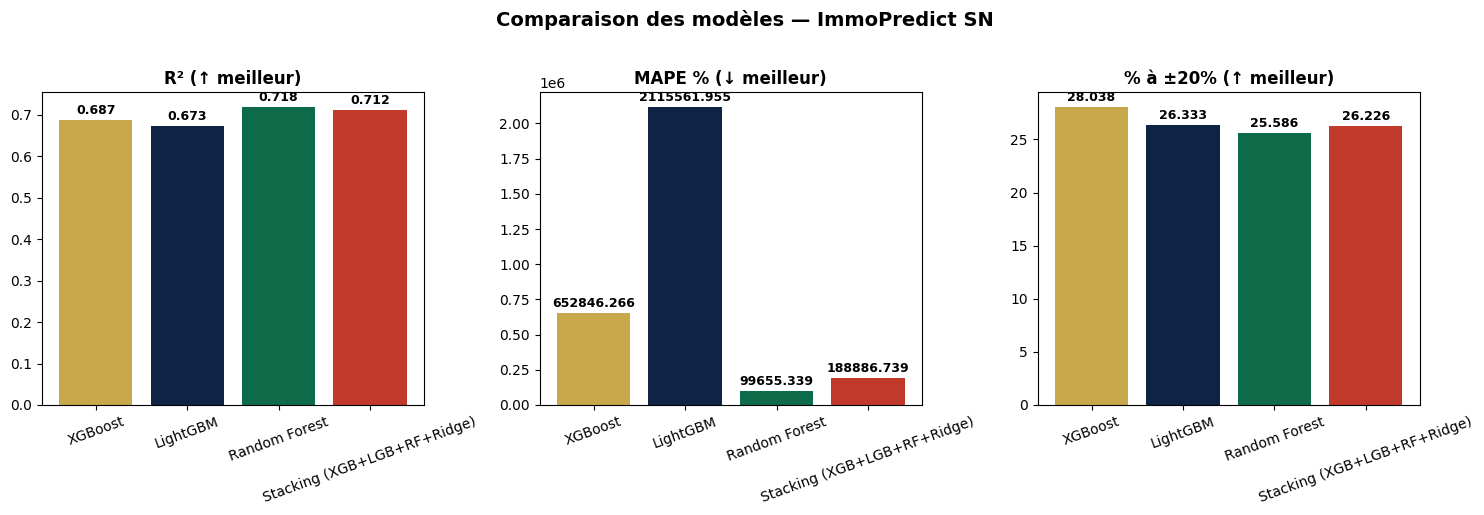


🏆 Meilleur modèle : Random Forest


In [25]:
# ── Comparaison des modèles ───────────────────────────────────
df_res = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('r2','R² (↑ meilleur)'), ('mape','MAPE % (↓ meilleur)'), ('pct20','% à ±20% (↑ meilleur)')]
colors = [GOLD, NAVY, GREEN, '#C0392B']

for i, (metric, title) in enumerate(metrics):
    vals = df_res[metric].astype(float)
    bars = axes[i].bar(df_res['name'], vals, color=colors[:len(df_res)])
    axes[i].set_title(title, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01*max(vals),
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des modèles — ImmoPredict SN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Meilleur modèle
best_name = df_res.loc[df_res['r2'].astype(float).idxmax(), 'name']
print(f'\n🏆 Meilleur modèle : {best_name}')

Calcul des valeurs SHAP pour XGBoost...


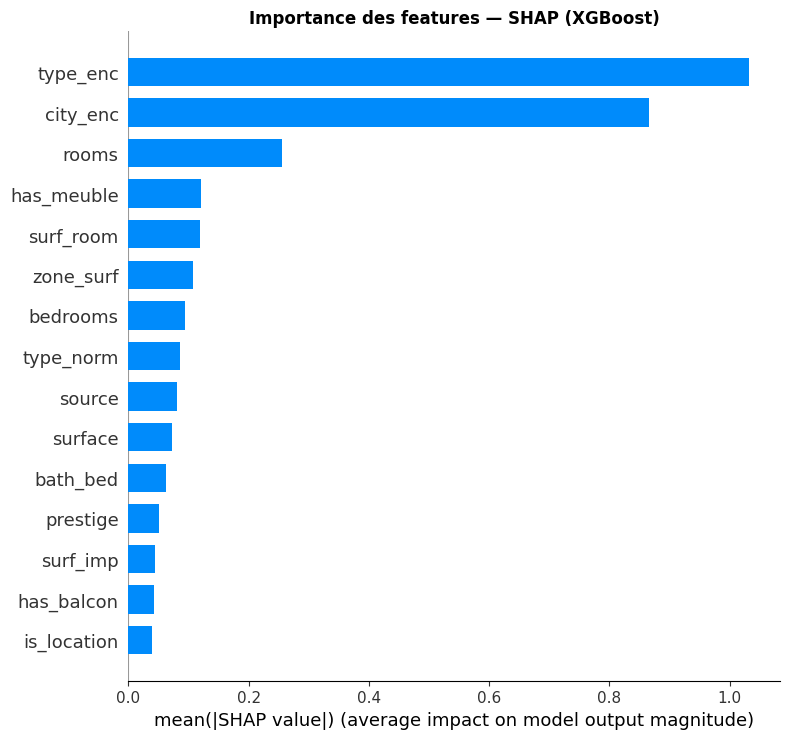

In [27]:
# ── Analyse SHAP ─────────────────────────────────────────────
print('Calcul des valeurs SHAP pour XGBoost...')

# Préparer les données pour SHAP
X_train_prep = xgb_model.named_steps['prep'].transform(X_train)
X_test_prep  = xgb_model.named_steps['prep'].transform(X_test)

explainer = shap.TreeExplainer(xgb_model.named_steps['model'])
shap_vals = explainer.shap_values(X_test_prep[:500])

feat_names = avail_num + avail_cat
shap.summary_plot(shap_vals, X_test_prep[:500],
                  feature_names=feat_names,
                  max_display=15, plot_type='bar', show=False)
plt.title('Importance des features — SHAP (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── Sauvegarder le meilleur modèle ───────────────────────────
models_map = {
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'Random Forest': rf_model,
    'Stacking (XGB+LGB+RF+Ridge)': stack_model,
}

best_key = df_res.loc[df_res['r2'].astype(float).idxmax(), 'name']
best_pipeline = models_map[best_key]
best_res = results[df_res['r2'].astype(float).idxmax()]

os.makedirs('../properties/ml', exist_ok=True)

# Sauvegarder sous le format attendu par predict.py
joblib.dump({
    'pipeline':             best_pipeline,
    'best_model_name':      best_key,
    'features':             avail_num + avail_cat,
    'numeric_features':     avail_num,
    'categorical_features': avail_cat,
    'metrics': {
        'r2':    round(best_res['r2'],  4),
        'mae':   round(best_res['mae'], 2),
        'rmse':  round(best_res['rmse'],2),
        'mape':  round(best_res['mape'],2),
        'pct20': round(best_res['pct20'],1),
        'pct30': round(best_res['pct30'],1),
    },
}, '../properties/ml/model.pkl')

# Sauvegarder aussi results.json
import json as _json
with open('../properties/ml/results.json','w') as f:
    _json.dump({
        'best_model': best_key,
        'metrics': {k: round(float(v),4) if isinstance(v,float) else v
                    for k,v in best_res.items()},
        'all_models': {k: {m: round(float(v),4) if isinstance(v,float) else v
                            for m,v in r.items()}
                       for k,r in results.items()},
    }, f, indent=2)

print(f'✅ Modèle {best_key} sauvegardé dans properties/ml/model.pkl')
print(f'   R² = {best_res["r2"]:.4f} | MAPE = {best_res["mape"]:.1f}% | ±20% = {best_res["pct20"]:.1f}%')

✅ Modèle Random Forest sauvegardé dans properties/ml/model.pkl
   R² = 0.7184 | MAPE = 99655.3% | ±20% = 25.6%
